# Image classifier

## Importación de librerías y paquetes y definición de constantes

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
# Modelado
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import set_random_seed
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings

### Definición de la semilla y los directorios de train y test

In [ ]:
set_random_seed(24)
data_dir_train = os.path.abspath(os.path.join(os.getcwd(), '..','..', 'dogs_vs_cats', 'train'))
data_dir_test = os.path.abspath(os.path.join(os.getcwd(), '..','..', 'dogs_vs_cats', 'test'))

In [ ]:
warnings.filterwarnings('ignore', category=FutureWarning, module='tensorflow')
warnings.filterwarnings('ignore', message='.*deprecated.*')

## Propuesta: utilizar un modelo VGG16 preentrenado con imagenes de imagenet y hacer un ajuste fino congelando capas y ajustando la tasa de aprendizaje

## Generación del conjunto de train y test: utilizamos un elemento `ImageDataGenerator` para crear los conjuntos de train y test

### Train

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

train_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=(128, 128),  
    batch_size=32,
    class_mode='categorical',     
    subset='training',
    )

Found 16000 images belonging to 2 classes.


### Validación

In [ ]:
val_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    )


Found 4000 images belonging to 2 classes.


### Obtener las primeras imágenes del conjunto de train

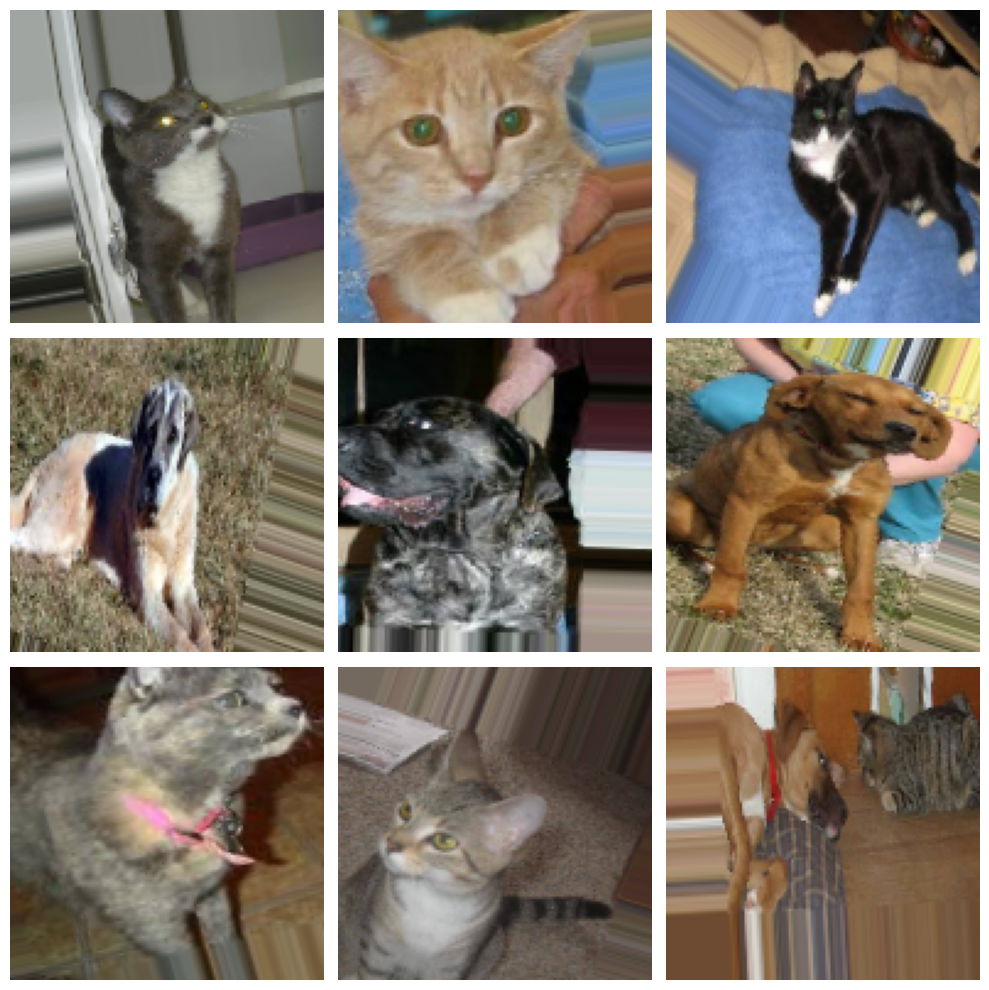

In [6]:
# Obtener un lote del generador
images, labels = next(train_generator)  # Siguiente lote

# Mostrar las primeras 9 imágenes
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

### Test

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    data_dir_test,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',   # Usar el mismo class_mode que en entrenamiento
    shuffle=False,              # Importante para evaluar o predecir
    )

Found 5000 images belonging to 2 classes.


#### Generamos el conjunto de train y test con `class_mode='categorical'` por que el modelo espera que los datos esten codificados en one-hot

## Generación y ajuste del modelo

### Tomado de los apuntes de la academia y modificado para nuestro caso particular

In [22]:

# Define el número de clases (reemplaza con tu número real de clases)
num_classes = 2 

# Carga el modelo preentrenado (sin la capa superior)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Congela todas las capas inicialmente
base_model.trainable = False

# Descongela selectivamente capas específicas para ajuste fino (por ejemplo, las últimas 3 capas convolucionales)
# Capas de VGG16: block1_conv1, block1_conv2, ..., block5_conv3
# Descongela capas en block5 (último bloque convolucional: block5_conv1, block5_conv2, block5_conv3)
for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True

# Añade nuevas capas
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)


# Crea el nuevo modelo
model = Model(inputs=base_model.input, outputs=predictions)

#### Compilamos: elegimos la función de pérdida `categorical_crossentropy` ya que la capa de salida utiliza una función de activación softmax, la cual espera que los datos esten codificados en one-hot y esta es la función de perdida que corresponde a ese tipo de salida y datos

In [23]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),  # Tasa de aprendizaje pequeña para capas preentrenadas y nuevas
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Generamos un callback de early_stop

In [24]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True
                           )

#### Entrenamos el modelo

In [25]:
# Entrena capas descongeladas (block5) + nuevas capas
model.fit(train_generator,
          epochs=20,
          validation_data=val_generator,
          callbacks=[early_stop] 
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1154s 2s/step - accuracy: 0.7699 - loss: 0.4674 - val_accuracy: 0.8758 - val_loss: 0.2861
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1269s 3s/step - accuracy: 0.8848 - loss: 0.2673 - val_accuracy: 0.8823 - val_loss: 0.2692
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1271s 3s/step - accuracy: 0.9010 - loss: 0.2319 - val_accuracy: 0.8932 - val_loss: 0.2386
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1273s 3s/step - accuracy: 0.9141 - loss: 0.2048 - val_accuracy: 0.9018 - val_loss: 0.2245
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1279s 3s/step - accuracy: 0.9181 - loss: 0.1948 - val_accuracy: 0.9122 - val_loss: 0.2112
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1289s 3s/step - accuracy: 0.9288 - loss: 0.1778 - val_accuracy: 0.8975 - val_loss: 0.2448
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1287s 3s/step - accuracy: 0.9273 - loss: 0.1798 - val_accuracy: 0.9190 - val_loss: 0.1974
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1283s 3s/step - accuracy: 0.9317 - loss: 0.1661 - 

#### Métricas para train

In [26]:
_, accuracy = model.evaluate(train_generator)

500/500 ━━━━━━━━━━━━━━━━━━━━ 908s 2s/step - accuracy: 0.9442 - loss: 0.1385


In [27]:
print('\nTrain accuracy:', accuracy)


Train accuracy: 0.9446250200271606


## Predicción

In [28]:
y_pred = model.predict(test_generator)
y_pred[:15]

157/157 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step


array([[9.99802053e-01, 1.97996080e-04],
       [9.97963786e-01, 2.03623809e-03],
       [9.99776304e-01, 2.23746800e-04],
       [9.99444544e-01, 5.55443112e-04],
       [9.76168334e-01, 2.38316003e-02],
       [9.99989390e-01, 1.06035377e-05],
       [9.87178206e-01, 1.28217805e-02],
       [9.73722756e-01, 2.62772776e-02],
       [9.91558671e-01, 8.44139513e-03],
       [9.99851465e-01, 1.48568215e-04],
       [9.99905348e-01, 9.46100117e-05],
       [9.99904275e-01, 9.57426673e-05],
       [9.44598258e-01, 5.54017611e-02],
       [9.99914885e-01, 8.50595316e-05],
       [9.98777330e-01, 1.22272247e-03]], dtype=float32)

In [29]:
y_pred_round = [[round(x,0) for x in val] for val in y_pred]
y_pred_round[:15]

[[1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0],
 [1.0, 0.0]]

#### Métricas para test

In [30]:
test_loss, test_acc = model.evaluate(test_generator, verbose=2)

157/157 - 218s - 1s/step - accuracy: 0.9472 - loss: 0.1292


In [31]:
print('\nTest accuracy:', test_acc)


Test accuracy: 0.9472000002861023


## Conclusiones
- ### Con la arquitectura completa de vgg16 el coste computacional es más alto, pero los resultados han sido mucho mejores
- ### Con un callback de earlystop el modelo ha necesitado 13 epocas de 20 impuestas para alcanzar el mejor resultado (unos 240 min)
- ### Obtenemos una precisión para el conjunto de test de 95% lo cual es bastante satisfactorio


## Guardar modelo

In [ ]:
model.save("../models/keras_128x128-VGG16_128-2.keras")